In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [8]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

In [12]:
pm   = pd.read_csv("PM2.5_index.csv")
hdi  = pd.read_csv("human-development-index.csv")
life = pd.read_csv("life-expectancy-hmd-unwpp.csv")

print("Raw shapes -> PM2.5:", pm.shape, "| HDI:", hdi.shape, "| LifeExp:", life.shape)
print("\nPM2.5 head:");          print(pm.head(3))
print("\nHDI head:");            print(hdi.head(3))
print("\nLife Expectancy head:");print(life.head(3))

Raw shapes -> PM2.5: (222, 5) | HDI: (192, 6) | LifeExp: (201, 4)

PM2.5 head:
                                         Series Name        Series Code  \
0  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   
1  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   
2  PM2.5 air pollution, mean annual exposure (mic...  EN.ATM.PM25.MC.M3   

  Country Name Country Code     2020 [YR2020]  
0  Afghanistan          AFG  46.0870936659706  
1      Albania          ALB  15.7070036417042  
2      Algeria          DZA  25.5526558310447  

HDI head:
        Entity Code  Year  Human Development Index  \
0  Afghanistan  AFG  2020                    0.501   
1      Albania  ALB  2020                    0.794   
2      Algeria  DZA  2020                    0.742   

  World region according to OWID  Human Development Index (Original Year)  
0                           Asia                                      NaN  
1                         Europe                

In [13]:
pm = pm.dropna(subset=["Country Code"]).copy()
pm = pm.rename(columns={
    "Country Name":   "Country",
    "Country Code":   "Code",
    "2020 [YR2020]":  "PM2_5",
})
pm["PM2_5"] = pd.to_numeric(pm["PM2_5"], errors="coerce")
pm = pm[["Country", "Code", "PM2_5"]]

# --- HDI
hdi = hdi.rename(columns={
    "Entity": "Country",
    "Human Development Index": "HDI",
    "World region according to OWID": "Region",
})
hdi = hdi[["Country", "Code", "HDI", "Region"]]

In [14]:
life = life.rename(columns={
    "Entity": "Country",
    "Life expectancy at birth, totals, period": "LifeExp",
})
life = life[["Country", "Code", "LifeExp"]]

print("Cleaned shapes ->", pm.shape, hdi.shape, life.shape)


# %% [Cell 4] Merge on ISO3 country code
df = (pm.merge(hdi[["Code", "HDI", "Region"]], on="Code", how="inner")
        .merge(life[["Code", "LifeExp"]],       on="Code", how="inner"))

print("Merged shape:", df.shape)
df.head()


Cleaned shapes -> (217, 3) (192, 4) (201, 3)
Merged shape: (192, 6)


,Country,Code,PM2_5,HDI,Region,LifeExp
0,Afghanistan,AFG,46.087094,0.501,Asia,61.4537
1,Albania,ALB,15.707004,0.794,Europe,77.8241
2,Algeria,DZA,25.552656,0.742,Africa,73.2568
3,Andorra,AND,9.080281,0.851,Europe,79.4177
4,Angola,AGO,25.145238,0.610,Africa,63.1164


In [16]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDtypes:")
print(df.dtypes)

# Drop the few rows with missing values
df = df.dropna().reset_index(drop=True)
print("\nFinal shape after dropping NA:", df.shape)

Missing values per column:
Country    0
Code       0
PM2_5      1
HDI        0
Region     1
LifeExp    0
dtype: int64

Dtypes:
Country     object
Code        object
PM2_5      float64
HDI        float64
Region      object
LifeExp    float64
dtype: object

Final shape after dropping NA: (190, 6)


In [17]:
print("Numeric summary:")
print(df[["PM2_5", "HDI", "LifeExp"]].describe().round(3))

print("\nCountries per region:")
print(df["Region"].value_counts())

Numeric summary:
         PM2_5      HDI  LifeExp
count  190.000  190.000  190.000
mean    24.141    0.727   71.667
std     15.034    0.148    7.300
min      4.895    0.386   50.596
25%     13.004    0.614   66.480
50%     20.301    0.742   72.128
75%     30.423    0.841   77.124
max     85.122    0.969   84.670

Countries per region:
Region
Africa           53
Asia             46
Europe           42
North America    23
Oceania          14
South America    12
Name: count, dtype: int64


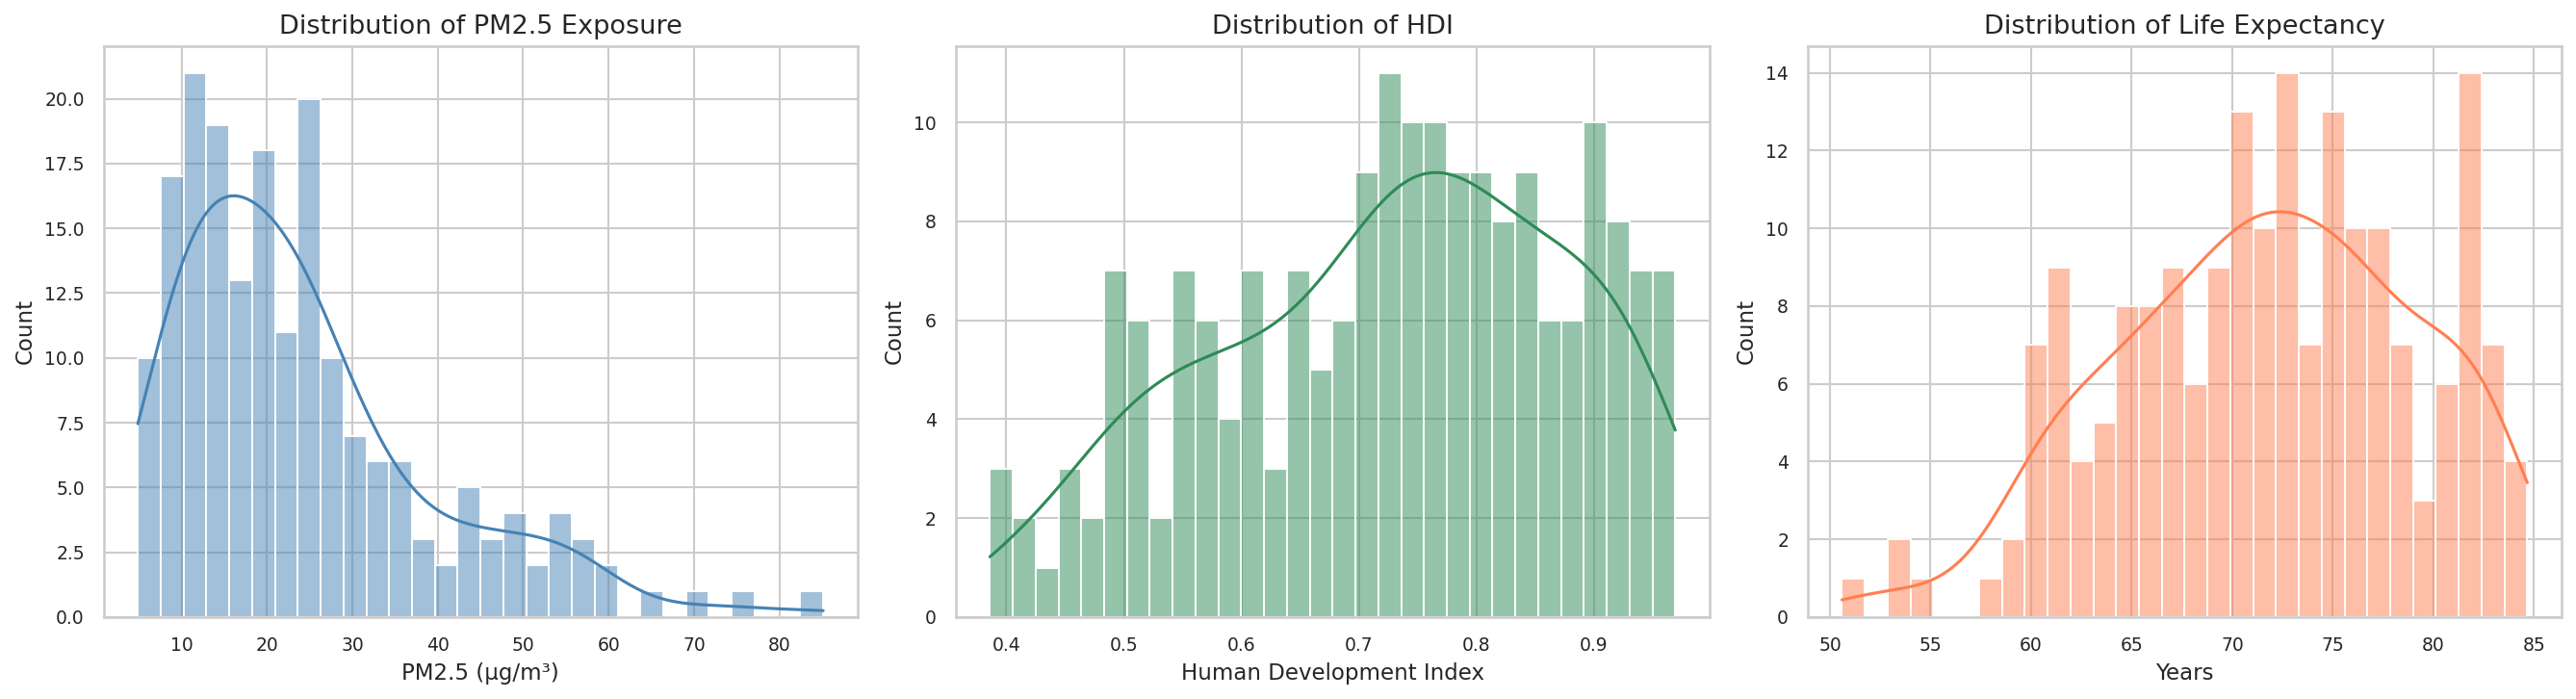

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["PM2_5"],   bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of PM2.5 Exposure")
axes[0].set_xlabel("PM2.5 (µg/m³)")

sns.histplot(df["HDI"],     bins=30, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribution of HDI")
axes[1].set_xlabel("Human Development Index")

sns.histplot(df["LifeExp"], bins=30, kde=True, ax=axes[2], color="coral")
axes[2].set_title("Distribution of Life Expectancy")
axes[2].set_xlabel("Years")

plt.tight_layout(); plt.show()


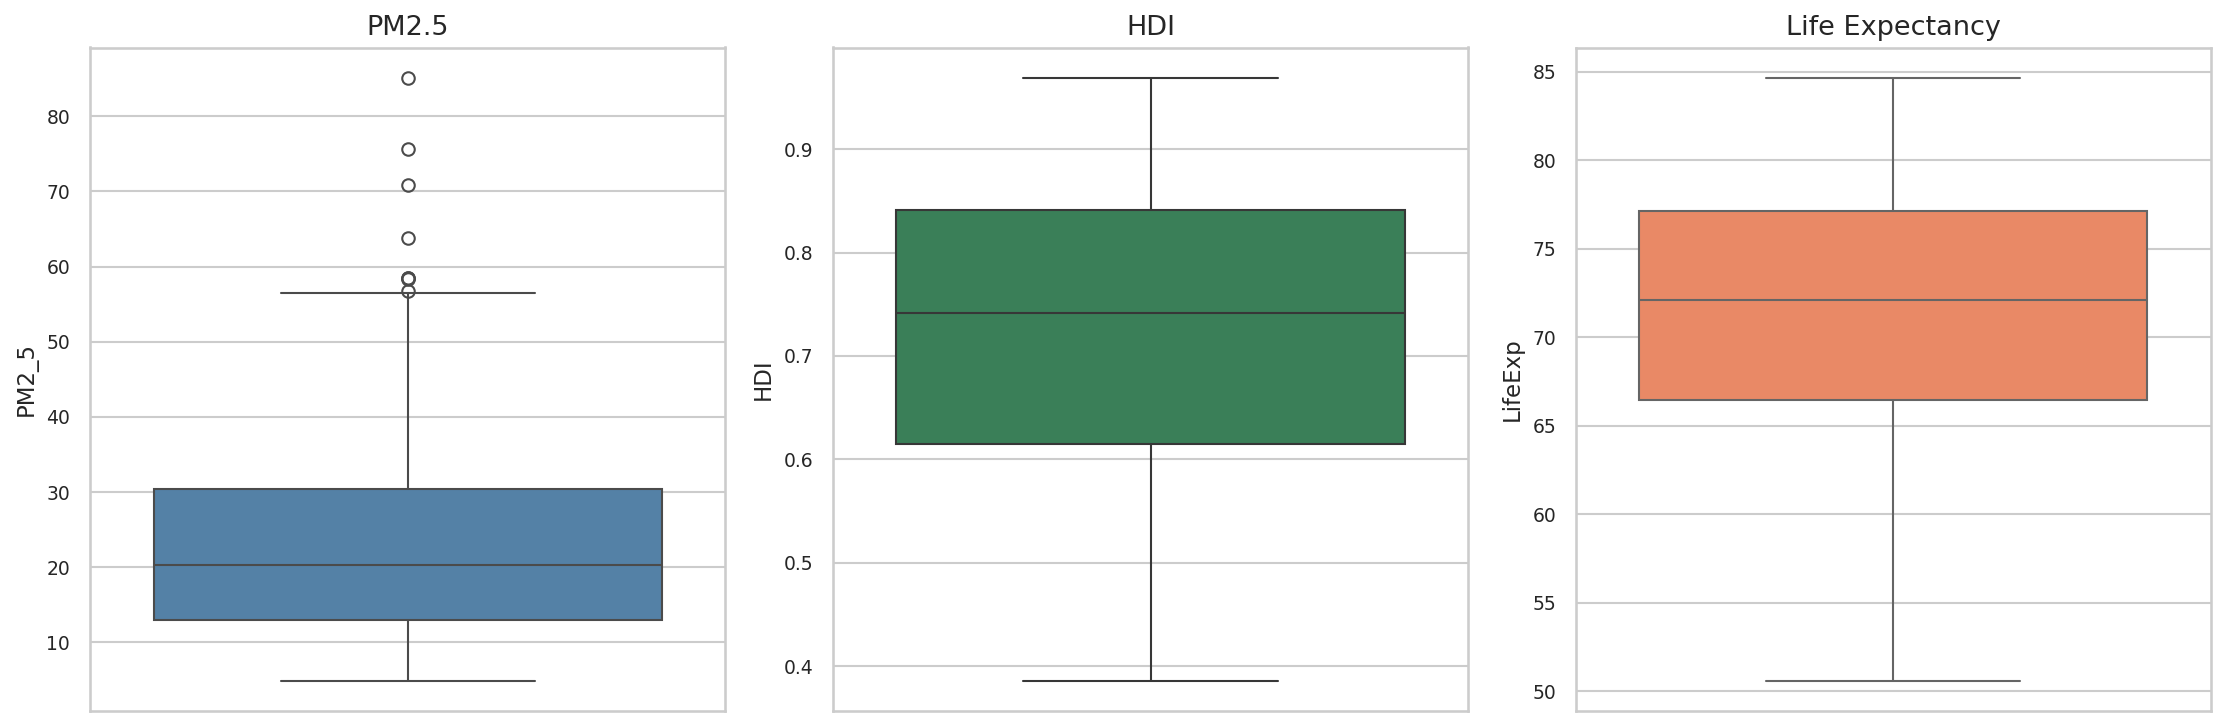

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df["PM2_5"],   ax=axes[0], color="steelblue"); axes[0].set_title("PM2.5")
sns.boxplot(y=df["HDI"],     ax=axes[1], color="seagreen");  axes[1].set_title("HDI")
sns.boxplot(y=df["LifeExp"], ax=axes[2], color="coral");     axes[2].set_title("Life Expectancy")
plt.tight_layout(); plt.show()

In [20]:
print("Skewness:")
print(df[["PM2_5", "HDI", "LifeExp"]].skew().round(3))

Skewness:
PM2_5      1.320
HDI       -0.340
LifeExp   -0.299
dtype: float64


Pearson correlation matrix:
         PM2_5    HDI  LifeExp
PM2_5    1.000 -0.566   -0.479
HDI     -0.566  1.000    0.905
LifeExp -0.479  0.905    1.000

Spearman correlation matrix:
         PM2_5    HDI  LifeExp
PM2_5    1.000 -0.621   -0.525
HDI     -0.621  1.000    0.915
LifeExp -0.525  0.915    1.000



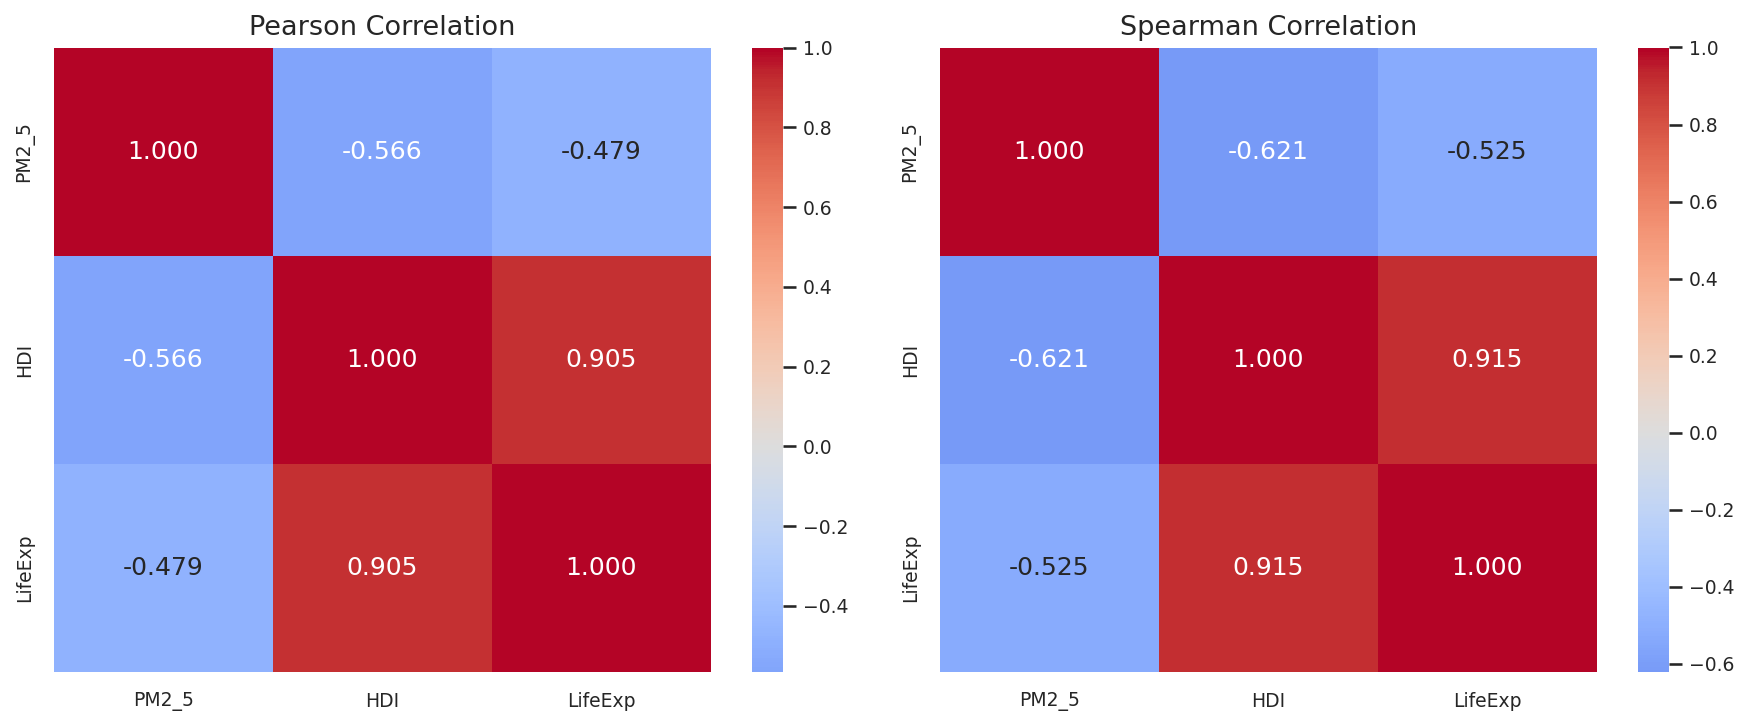

In [46]:
pearson_corr  = df[["PM2_5", "HDI", "LifeExp"]].corr(method="pearson")
spearman_corr = df[["PM2_5", "HDI", "LifeExp"]].corr(method="spearman")

print("Pearson correlation matrix:")
print(pearson_corr.round(3))
print("\nSpearman correlation matrix:")
print(spearman_corr.round(3))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pearson_corr,  annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout(); plt.show()

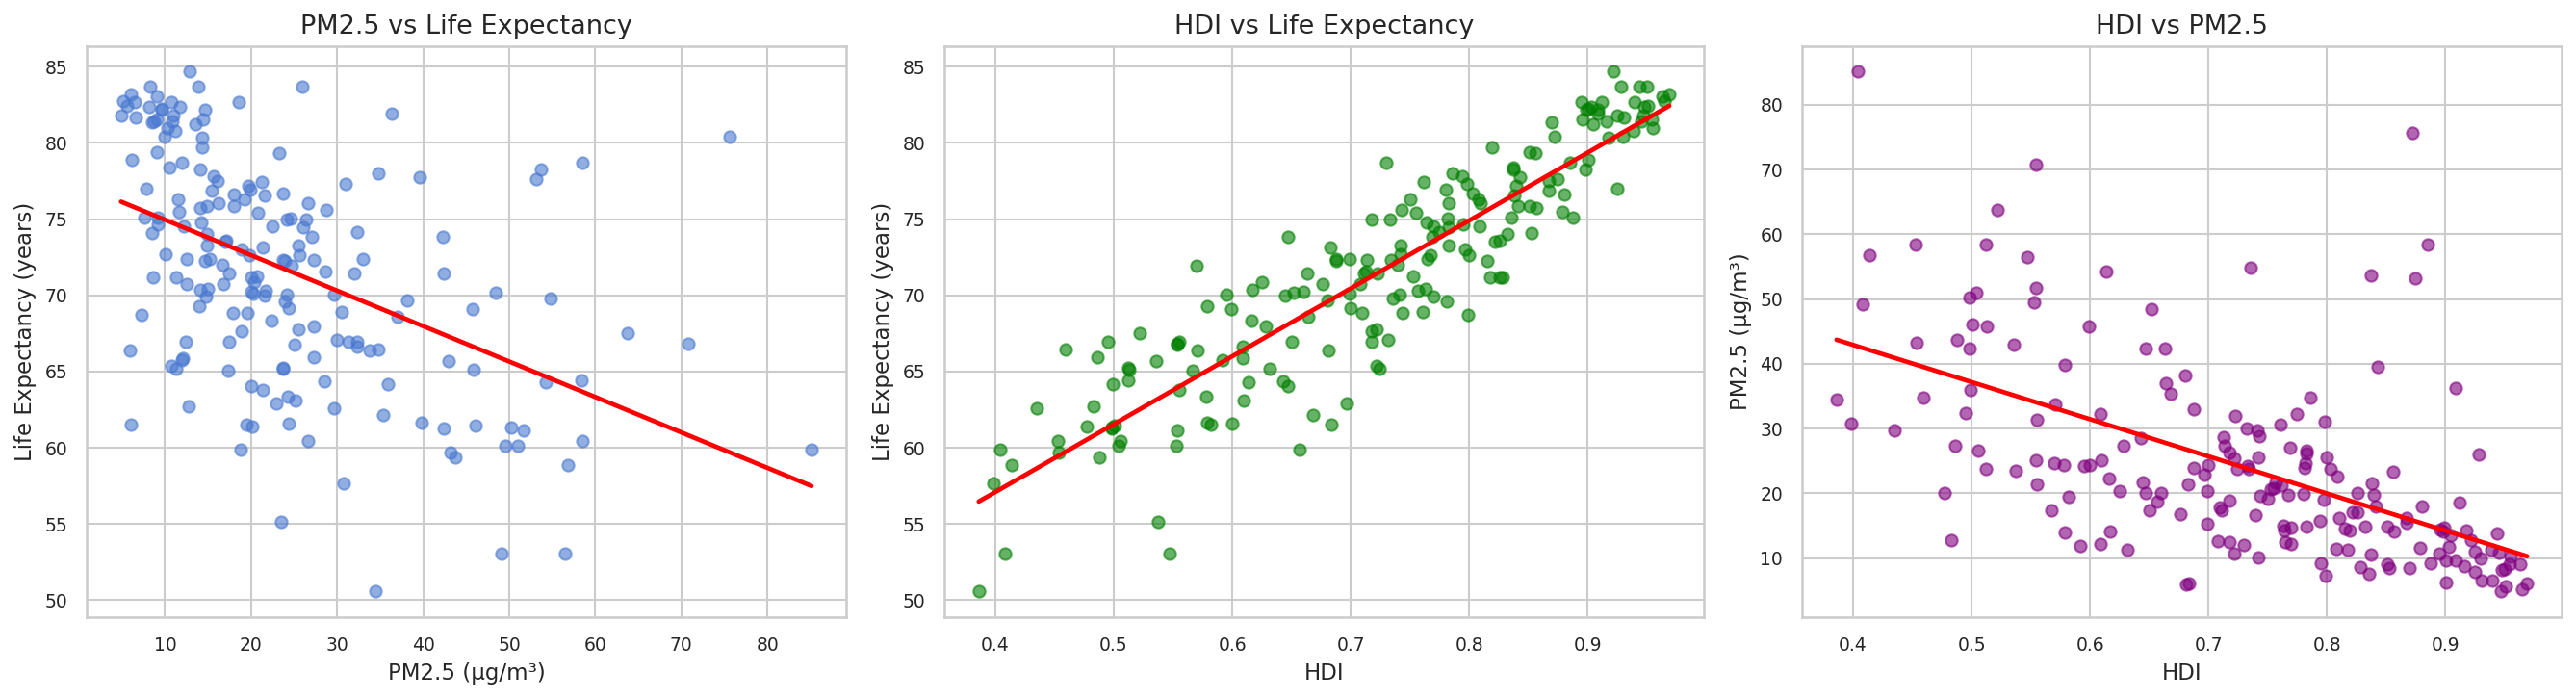

In [23]:
#Bivariate scatter plots with visual trend lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x="PM2_5", y="LifeExp", ax=axes[0], ci=None,
            scatter_kws={"alpha": 0.6, "s": 35}, line_kws={"color": "red"})
axes[0].set_title("PM2.5 vs Life Expectancy")
axes[0].set_xlabel("PM2.5 (µg/m³)"); axes[0].set_ylabel("Life Expectancy (years)")

sns.regplot(data=df, x="HDI", y="LifeExp", ax=axes[1], ci=None, color="green",
            scatter_kws={"alpha": 0.6, "s": 35}, line_kws={"color": "red"})
axes[1].set_title("HDI vs Life Expectancy")
axes[1].set_xlabel("HDI"); axes[1].set_ylabel("Life Expectancy (years)")

sns.regplot(data=df, x="HDI", y="PM2_5", ax=axes[2], ci=None, color="purple",
            scatter_kws={"alpha": 0.6, "s": 35}, line_kws={"color": "red"})
axes[2].set_title("HDI vs PM2.5")
axes[2].set_xlabel("HDI"); axes[2].set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout(); plt.show()

In [24]:
#HDI grouping (UNDP thresholds) - the moderating variable
def hdi_group(h):
    if h < 0.55:   return "Low"
    elif h < 0.70: return "Medium"
    elif h < 0.80: return "High"
    else:          return "Very High"

df["HDI_Group"] = df["HDI"].apply(hdi_group)
group_order = ["Low", "Medium", "High", "Very High"]

print("Counts per HDI group:")
print(df["HDI_Group"].value_counts().reindex(group_order))

print("\nMean PM2.5 and Life Expectancy per HDI group:")
print(df.groupby("HDI_Group")[["PM2_5", "LifeExp"]]
        .agg(["mean", "median", "std", "count"])
        .round(2)
        .reindex(group_order))

Counts per HDI group:
HDI_Group
Low          27
Medium       47
High         50
Very High    66
Name: count, dtype: int64

Mean PM2.5 and Life Expectancy per HDI group:
           PM2_5                     LifeExp                   
            mean median    std count    mean median   std count
HDI_Group                                                      
Low        41.69  43.00  15.84    27   61.13  61.34  4.42    27
Medium     27.32  24.14  13.57    47   66.96  66.79  3.86    47
High       21.76  21.02   8.40    50   72.31  72.35  3.42    50
Very High  16.51  13.17  13.21    66   78.84  79.38  3.62    66


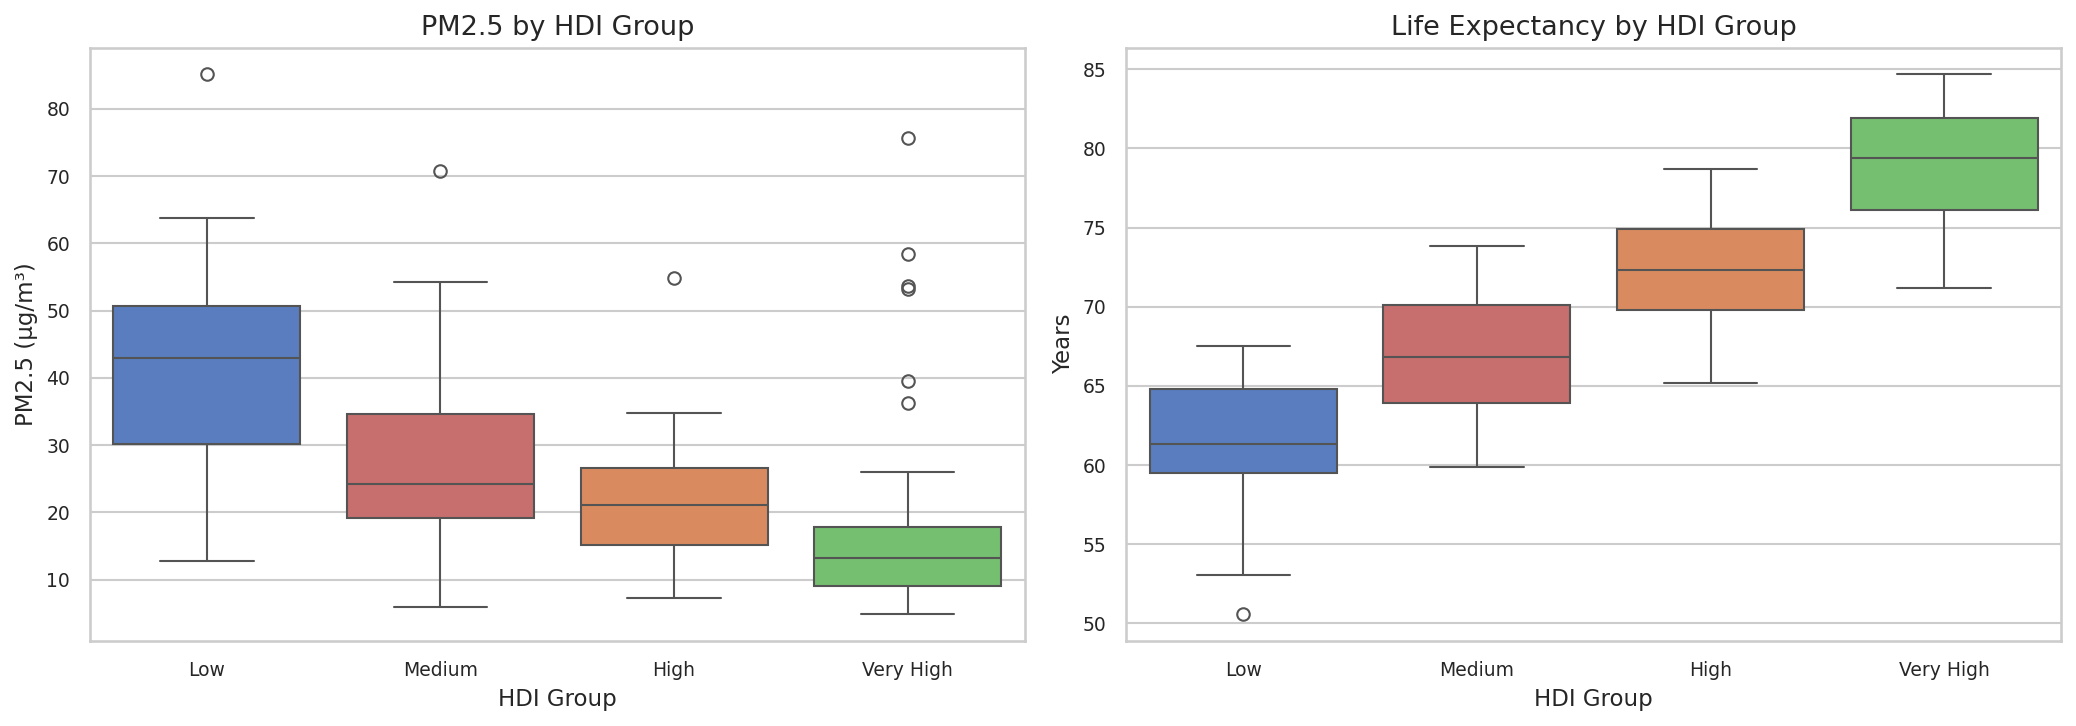

In [38]:
# Boxplots by HDI group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="HDI_Group", y="PM2_5", order=group_order,
            ax=axes[0],  hue="HDI_Group", legend= False)
axes[0].set_title("PM2.5 by HDI Group")
axes[0].set_xlabel("HDI Group"); axes[0].set_ylabel("PM2.5 (µg/m³)")

sns.boxplot(data=df, x="HDI_Group", y="LifeExp", order=group_order,
            ax=axes[1], hue="HDI_Group", legend= False)
axes[1].set_title("Life Expectancy by HDI Group")
axes[1].set_xlabel("HDI Group"); axes[1].set_ylabel("Years")
plt.tight_layout(); plt.show()

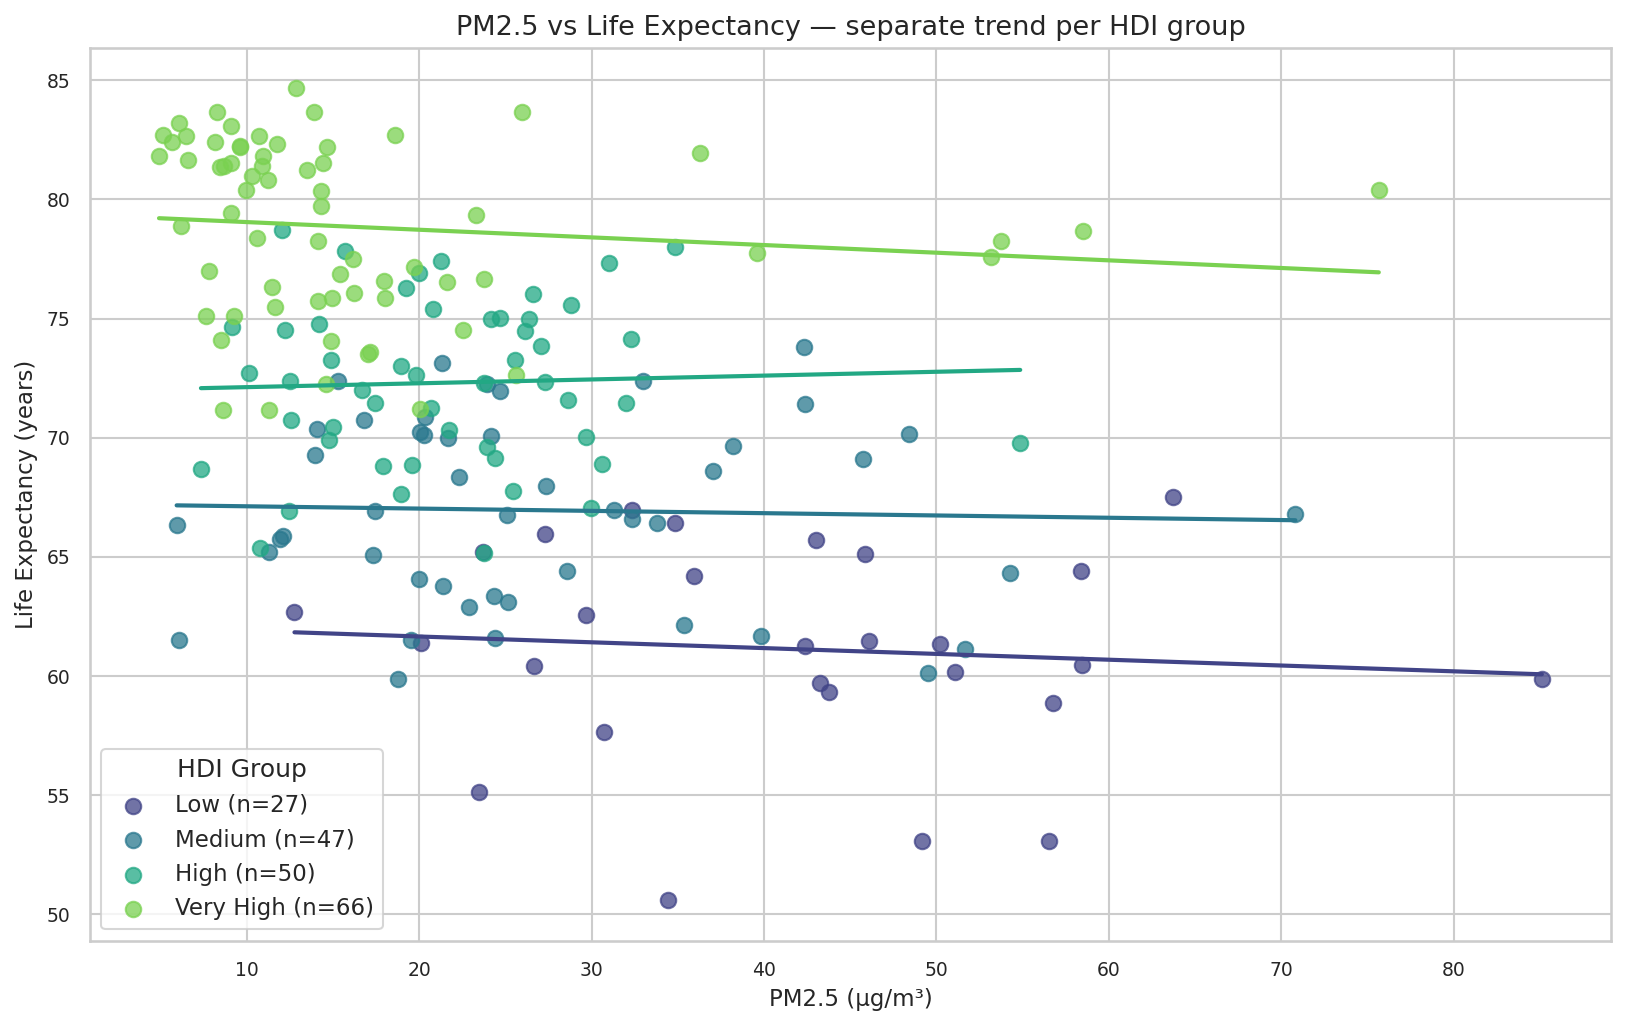

In [27]:
# Moderation visualization:
# PM2.5 vs Life Expectancy with separate trend lines per HDI group
plt.figure(figsize=(11, 7))
palette = sns.color_palette("viridis", n_colors=4)

for color, grp in zip(palette, group_order):
    sub = df[df["HDI_Group"] == grp]
    plt.scatter(sub["PM2_5"], sub["LifeExp"], color=color,
                alpha=0.75, s=55, label=f"{grp} (n={len(sub)})")
    if len(sub) > 2:
        # Visual trend line using a simple polynomial fit (descriptive only)
        slope, intercept = np.polyfit(sub["PM2_5"], sub["LifeExp"], 1)
        x_line = np.linspace(sub["PM2_5"].min(), sub["PM2_5"].max(), 50)
        plt.plot(x_line, intercept + slope * x_line, color=color, lw=2)

plt.title("PM2.5 vs Life Expectancy — separate trend per HDI group")
plt.xlabel("PM2.5 (µg/m³)"); plt.ylabel("Life Expectancy (years)")
plt.legend(title="HDI Group"); plt.tight_layout(); plt.show()

In [28]:
# Pearson correlation coefficient INSIDE each HDI group (r-values per group)
print("PM2.5 vs Life Expectancy correlation within each HDI group:")
within = (df.groupby("HDI_Group")[["PM2_5", "LifeExp"]]
            .corr().unstack().iloc[:, 1]
            .reindex(group_order)
            .round(3))
within.name = "r (PM2.5, LifeExp)"
print(within)

PM2.5 vs Life Expectancy correlation within each HDI group:
HDI_Group
Low         -0.087
Medium      -0.034
High         0.040
Very High   -0.117
Name: r (PM2.5, LifeExp), dtype: float64


Removed 6 Gulf countries (190 -> 184)

Overall Pearson correlations (descriptive):
  With Gulf    : {'PM2_5': 1.0, 'HDI': -0.566, 'LifeExp': -0.479}
  Without Gulf : {'PM2_5': 1.0, 'HDI': -0.687, 'LifeExp': -0.597}

PM2.5 vs LifeExp correlation within HDI groups:
           with_gulf  without_gulf
HDI_Group                         
Low           -0.087        -0.087
Medium        -0.034        -0.034
High           0.040         0.040
Very High     -0.117        -0.363




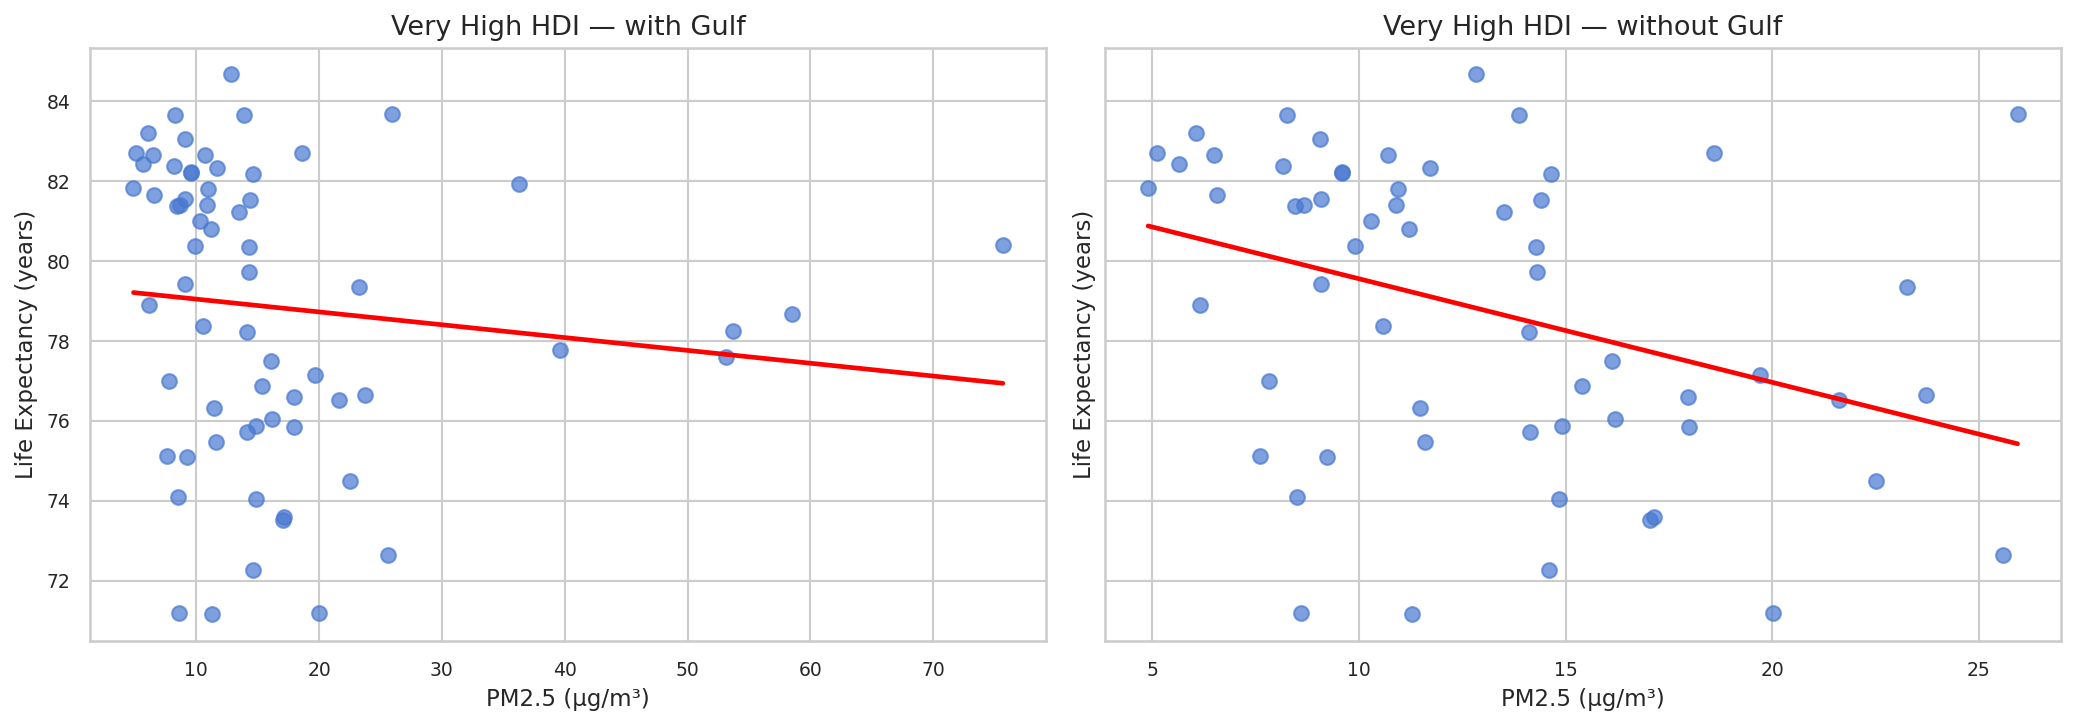

In [43]:
# Sensitivity analysis - excluding Gulf states

gulf_codes = ["QAT", "BHR", "KWT", "ARE", "SAU", "OMN"]
df_nogulf = df[~df["Code"].isin(gulf_codes)].copy()

print(f"Removed {len(df) - len(df_nogulf)} Gulf countries "
      f"({len(df)} -> {len(df_nogulf)})")

print("\nOverall Pearson correlations (descriptive):")
print("  With Gulf    :", df[['PM2_5','HDI','LifeExp']].corr().round(3).iloc[0].to_dict())
print("  Without Gulf :", df_nogulf[['PM2_5','HDI','LifeExp']].corr().round(3).iloc[0].to_dict())

print("\nPM2.5 vs LifeExp correlation within HDI groups:")
comp = pd.DataFrame({
    "with_gulf":    df.groupby("HDI_Group")[["PM2_5","LifeExp"]]
                       .corr().unstack().iloc[:,1].reindex(group_order),
    "without_gulf": df_nogulf.groupby("HDI_Group")[["PM2_5","LifeExp"]]
                       .corr().unstack().iloc[:,1].reindex(group_order),
}).round(3)
print(comp)

# Side-by-side scatter for the Very High HDI group
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, data, title in [
    (axes[0], df[df["HDI_Group"]=="Very High"],        "Very High HDI — with Gulf"),
    (axes[1], df_nogulf[df_nogulf["HDI_Group"]=="Very High"], "Very High HDI — without Gulf"),
]:
    print()
    sns.regplot(data=data, x="PM2_5", y="LifeExp", ax=ax, ci=None,
                scatter_kws={"alpha":0.7, "s":50}, line_kws={"color":"red"})
    ax.set_title(title)
    ax.set_xlabel("PM2.5 (µg/m³)"); ax.set_ylabel("Life Expectancy (years)")
plt.tight_layout(); plt.show()

Mean values by region:
               PM2_5   HDI  LifeExp
Region                             
Africa         35.56  0.57    63.98
Oceania        10.78  0.71    69.58
South America  18.32  0.76    73.06
North America  18.78  0.76    73.16
Asia           29.84  0.74    73.60
Europe         12.55  0.88    78.73



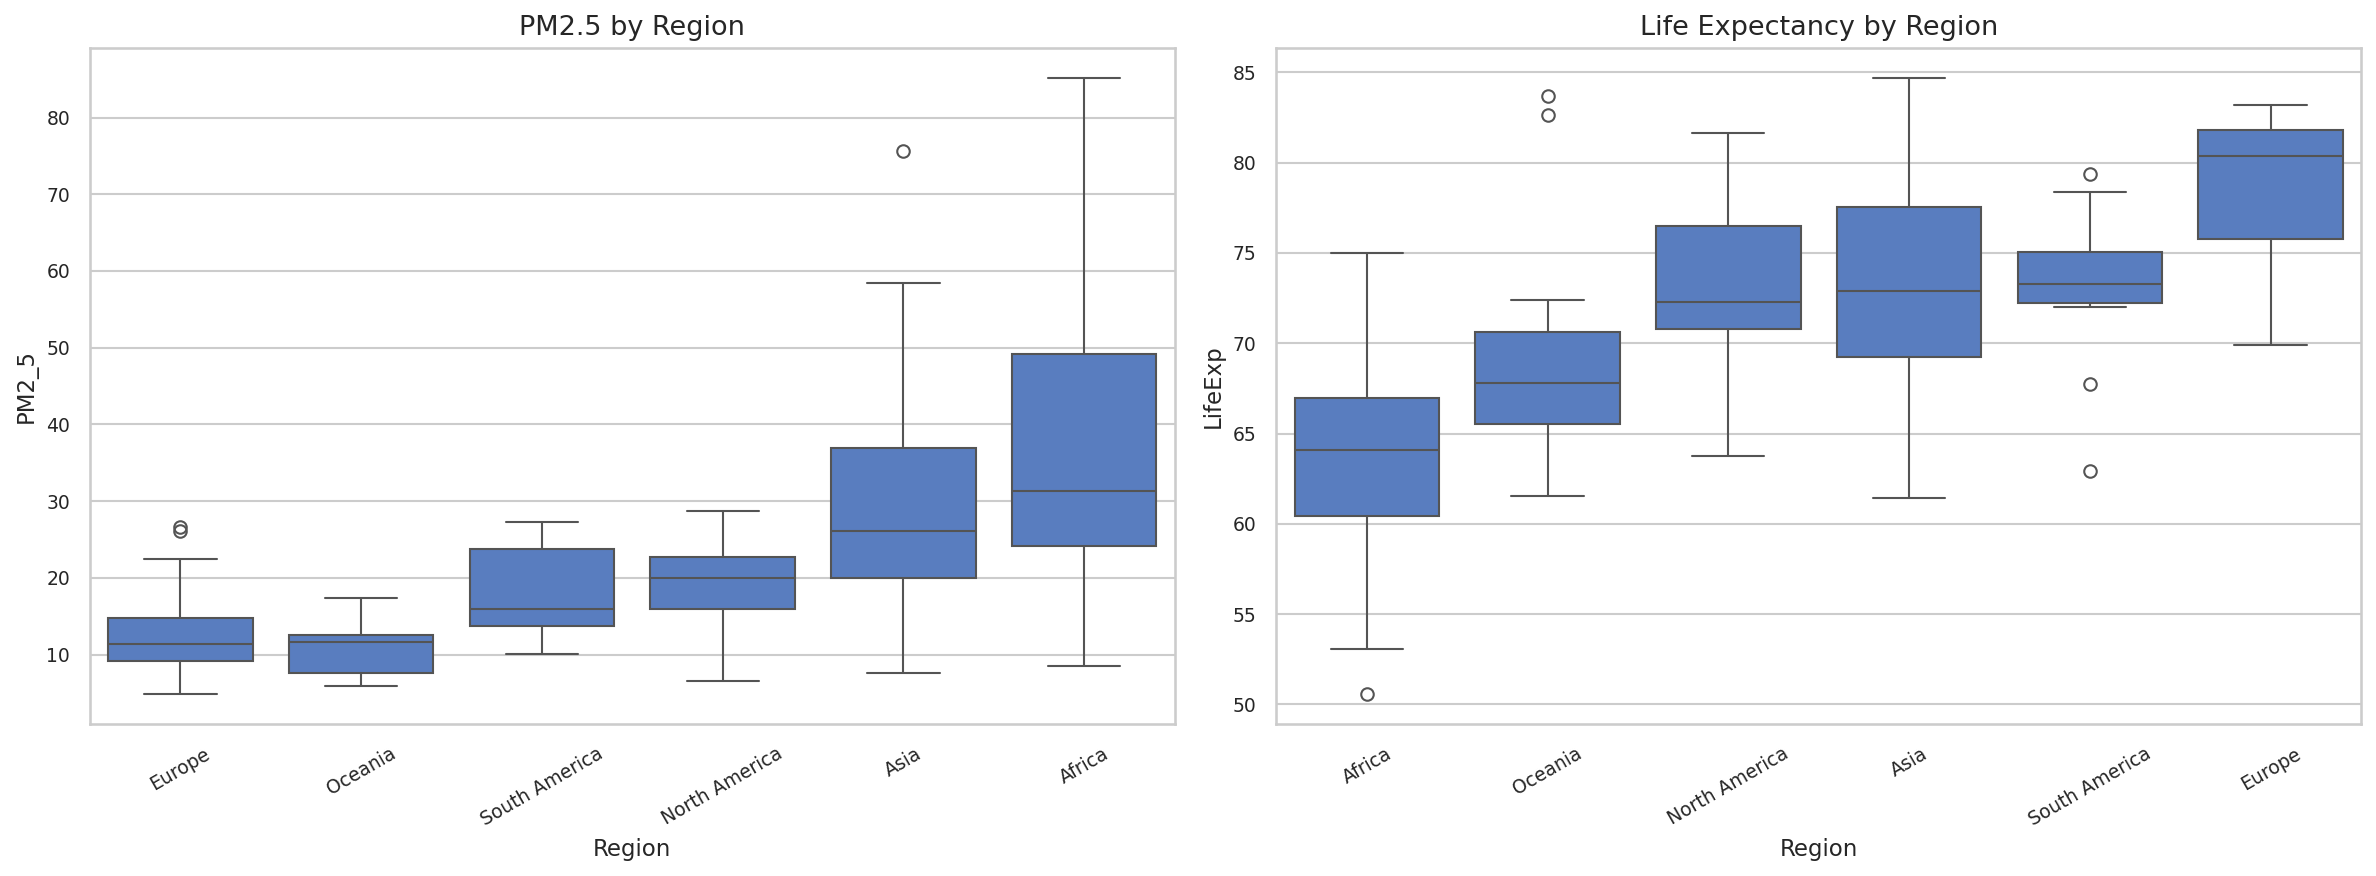

In [44]:
# Regional analysis
print("Mean values by region:")
print(df.groupby("Region")[["PM2_5", "HDI", "LifeExp"]]
        .mean().round(2).sort_values("LifeExp"))

print()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x="Region", y="PM2_5", ax=axes[0],
            order=df.groupby("Region")["PM2_5"].median().sort_values().index)
axes[0].set_title("PM2.5 by Region"); axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="Region", y="LifeExp", ax=axes[1],
            order=df.groupby("Region")["LifeExp"].median().sort_values().index)
axes[1].set_title("Life Expectancy by Region"); axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

In [40]:
# Top / bottom countries
print("Top 10 most polluted countries (PM2.5):")
print(df.nlargest(10, "PM2_5")[["Country", "PM2_5", "LifeExp", "HDI", "HDI_Group"]]
        .to_string(index=False))

print("\nTop 10 cleanest countries (lowest PM2.5):")
print(df.nsmallest(10, "PM2_5")[["Country", "PM2_5", "LifeExp", "HDI", "HDI_Group"]]
        .to_string(index=False))

print("\nTop 10 highest life expectancy:")
print(df.nlargest(10, "LifeExp")[["Country", "PM2_5", "LifeExp", "HDI", "HDI_Group"]]
        .to_string(index=False))

print("\nBottom 10 lowest life expectancy:")
print(df.nsmallest(10, "LifeExp")[["Country", "PM2_5", "LifeExp", "HDI", "HDI_Group"]]
        .to_string(index=False))

Top 10 most polluted countries (PM2.5):
         Country     PM2_5  LifeExp   HDI HDI_Group
           Niger 85.122346  59.8903 0.404       Low
           Qatar 75.663033  80.4095 0.872 Very High
      Mauritania 70.822444  66.7943 0.554    Medium
         Senegal 63.740221  67.4961 0.522       Low
         Bahrain 58.495063  78.6833 0.885 Very High
    Burkina Faso 58.470676  60.4536 0.453       Low
     Gambia, The 58.364040  64.4183 0.512       Low
            Mali 56.783049  58.8577 0.414       Low
         Nigeria 56.531329  53.0724 0.547       Low
Egypt, Arab Rep. 54.858706  69.7897 0.736      High

Top 10 cleanest countries (lowest PM2.5):
    Country    PM2_5  LifeExp   HDI HDI_Group
    Finland 4.895181  81.8219 0.947 Very High
    Iceland 5.105548  82.7113 0.965 Very High
     Sweden 5.636708  82.4271 0.951 Very High
     Tuvalu 5.917801  66.3567 0.681    Medium
     Norway 6.055897  83.1953 0.969 Very High
      Nauru 6.064355  61.5271 0.684    Medium
    Estonia 6.145733  7

In [45]:
# Quick descriptive summary printed at the end
print()
print("EDA SUMMARY")
print()
print(f"Countries analysed       : {len(df)}")
print(f"Mean PM2.5  (µg/m³)      : {df['PM2_5'].mean():.2f}")
print(f"Mean HDI                 : {df['HDI'].mean():.3f}")
print(f"Mean Life Expectancy (y) : {df['LifeExp'].mean():.2f}")
print()
print("Pearson correlations (descriptive):")
print(f"  PM2.5  vs LifeExp : r = {pearson_corr.loc['PM2_5','LifeExp']:+.3f}")
print(f"  HDI    vs LifeExp : r = {pearson_corr.loc['HDI','LifeExp']:+.3f}")
print(f"  PM2.5  vs HDI     : r = {pearson_corr.loc['PM2_5','HDI']:+.3f}")
print()
print("Initial observations:")
print(" - Globally, higher PM2.5 tends to coincide with lower life expectancy.")
print(" - HDI shows a much stronger positive association with life expectancy.")
print(" - Within HDI groups the PM2.5/LifeExp link visibly weakens, suggesting")
print("   HDI may moderate (or confound) the pollution-health relationship.")


EDA SUMMARY

Countries analysed       : 190
Mean PM2.5  (µg/m³)      : 24.14
Mean HDI                 : 0.727
Mean Life Expectancy (y) : 71.67

Pearson correlations (descriptive):
  PM2.5  vs LifeExp : r = -0.479
  HDI    vs LifeExp : r = +0.905
  PM2.5  vs HDI     : r = -0.566

Initial observations:
 - Globally, higher PM2.5 tends to coincide with lower life expectancy.
 - HDI shows a much stronger positive association with life expectancy.
 - Within HDI groups the PM2.5/LifeExp link visibly weakens, suggesting
   HDI may moderate (or confound) the pollution-health relationship.
